In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np

from src.activations import relu, relu_derivative, softmax

In [3]:
x = np.array([-3, -1, 0, 2, 5])

print(relu(x))

[0 0 0 2 5]


In [4]:
print(relu_derivative(x))

[0. 0. 0. 1. 1.]


In [5]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [0.5, 2.5, 1.0]
])

probabilities = softmax(logits)

print(probabilities)
print(probabilities.sum(axis=1))

[[0.65900114 0.24243297 0.09856589]
 [0.09962365 0.73612472 0.16425163]]
[1. 1.]


In [6]:
from src.losses import cross_entropy_loss

In [7]:
y_true = np.array([
    [0, 0, 0, 0, 1]
])

y_pred_good = np.array([
    [0.01, 0.01, 0.01, 0.01, 0.96]
])

y_pred_bad = np.array([
    [0.20, 0.20, 0.20, 0.20, 0.20]
])

In [8]:
print("Good prediction loss:", cross_entropy_loss(y_true, y_pred_good))
print("Bad prediction loss:", cross_entropy_loss(y_true, y_pred_bad))

Good prediction loss: 0.040821994520255166
Bad prediction loss: 1.6094379124341003


In [9]:
from src.layers import DenseLayer

In [10]:
layer = DenseLayer(784, 128)

In [11]:
print("Weights shape:", layer.weights.shape)
print("Bias shape:", layer.biases.shape)

Weights shape: (784, 128)
Bias shape: (1, 128)


In [12]:
X_batch = np.random.rand(32, 784)

In [13]:
Z = layer.forward(X_batch)

print("Input shape:", X_batch.shape)
print("Output shape:", Z.shape)

Input shape: (32, 784)
Output shape: (32, 128)


In [14]:

dZ = np.random.rand(32, 128)

In [15]:
dX = layer.backward(dZ)

print("dX shape:", dX.shape)
print("dW shape:", layer.dweights.shape)
print("db shape:", layer.dbiases.shape)

dX shape: (32, 784)
dW shape: (784, 128)
db shape: (1, 128)


In [16]:
from src.network import NeuralNetwork

In [17]:
model = NeuralNetwork()

In [18]:
X_batch = np.random.rand(32, 784)

In [19]:
predictions = model.forward(X_batch)

print("Prediction shape:", predictions.shape)

Prediction shape: (32, 10)


In [20]:
print(predictions[0])

[0.10010734 0.09932581 0.10065527 0.10159476 0.09901985 0.10059839
 0.09775014 0.09832942 0.10040865 0.10221036]


In [21]:
print(predictions[0].sum())

1.0


In [22]:
X_batch = np.random.rand(32, 784)

In [23]:
y_batch = np.zeros((32, 10))
y_batch[np.arange(32), np.random.randint(0, 10, 32)] = 1

In [24]:
predictions = model.forward(X_batch)

In [25]:
model.backward(y_batch)

In [26]:
print("Layer 1 dW:", model.layer1.dweights.shape)
print("Layer 1 db:", model.layer1.dbiases.shape)

print("Layer 2 dW:", model.layer2.dweights.shape)
print("Layer 2 db:", model.layer2.dbiases.shape)

Layer 1 dW: (784, 128)
Layer 1 db: (1, 128)
Layer 2 dW: (128, 10)
Layer 2 db: (1, 10)


In [27]:
predictions = model.forward(X_batch)
model.backward(y_batch)

In [28]:
old_weight = model.layer1.weights[0, 0]

In [29]:
model.update_parameters(learning_rate=0.01)

In [30]:
new_weight = model.layer1.weights[0, 0]

print("Old weight:", old_weight)
print("New weight:", new_weight)

Old weight: -0.017044048947166122
New weight: -0.017031266640410835


In [31]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml(
    name="mnist_784",
    version=1,
    as_frame=False
)

X = mnist.data
y = mnist.target.astype(np.int64)

In [32]:
X_train = X[:60000]
y_train_labels = y[:60000]

X_test = X[60000:]
y_test_labels = y[60000:]

X_train = X_train / 255.0
X_test = X_test / 255.0

In [33]:
def one_hot_encode(y, num_classes=10):
    encoded = np.zeros((y.shape[0], num_classes))
    encoded[np.arange(y.shape[0]), y] = 1
    return encoded


y_train = one_hot_encode(y_train_labels)
y_test = one_hot_encode(y_test_labels)

In [34]:
model.train(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    learning_rate=0.01
)

Epoch 1/5 - Loss: 1.8179
Epoch 2/5 - Loss: 0.6744
Epoch 3/5 - Loss: 0.4566
Epoch 4/5 - Loss: 0.3900
Epoch 5/5 - Loss: 0.3561


{'loss': [np.float64(1.8178781406253963),
  np.float64(0.674389120832757),
  np.float64(0.4565759314193131),
  np.float64(0.3900281083876144),
  np.float64(0.35610709282688524)]}

In [35]:
test_accuracy = model.accuracy(X_test, y_test_labels)

print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.9050


In [36]:
predictions = model.predict(X_test)

In [37]:
incorrect = predictions != y_test_labels

print("Incorrect predictions:", incorrect.sum())
print("Correct predictions:", (~incorrect).sum())

Incorrect predictions: 950
Correct predictions: 9050


In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_labels, predictions)

print(cm)

[[ 955    0    4    2    0    6    9    2    2    0]
 [   0 1111    1    3    0    2    4    1   13    0]
 [  12   11  905   14   18    1   18   16   31    6]
 [   3    0   22  906    0   36    1   19   14    9]
 [   1    1    5    1  917    1   12    2    5   37]
 [  17    3    6   52   13  731   19   11   29   11]
 [  16    3    5    0   17   14  899    1    3    0]
 [   6   12   26    4    8    0    0  933    3   36]
 [   7    9   14   33   15   36   18   13  807   22]
 [  11    8    3   10   47   12    1   28    3  886]]


In [39]:
import matplotlib.pyplot as plt

incorrect_indices = np.where(predictions != y_test_labels)[0]

print("Number of incorrect predictions:", len(incorrect_indices))

Number of incorrect predictions: 950


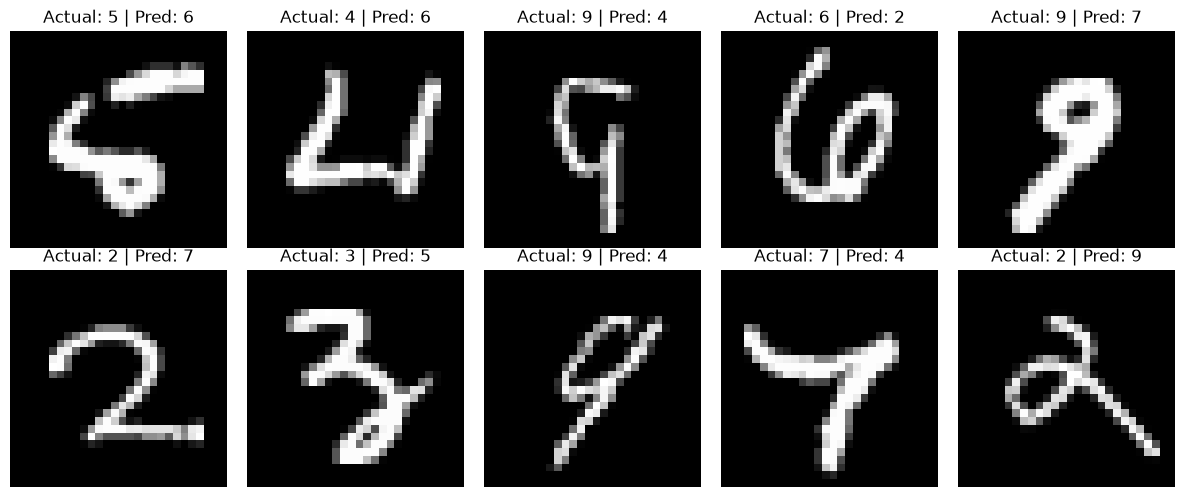

In [40]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, index in zip(axes.ravel(), incorrect_indices[:10]):
    ax.imshow(X_test[index].reshape(28, 28), cmap="gray")
    ax.set_title(
        f"Actual: {y_test_labels[index]} | Pred: {predictions[index]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [41]:
history_numpy = model.train(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    learning_rate=0.01
)

Epoch 1/5 - Loss: 0.3344
Epoch 2/5 - Loss: 0.3179
Epoch 3/5 - Loss: 0.3041
Epoch 4/5 - Loss: 0.2919
Epoch 5/5 - Loss: 0.2817


In [42]:
print(history_numpy)

{'loss': [np.float64(0.33439142236869346), np.float64(0.31791108728268386), np.float64(0.3040692550174531), np.float64(0.2918818555638483), np.float64(0.2816874041634201)]}


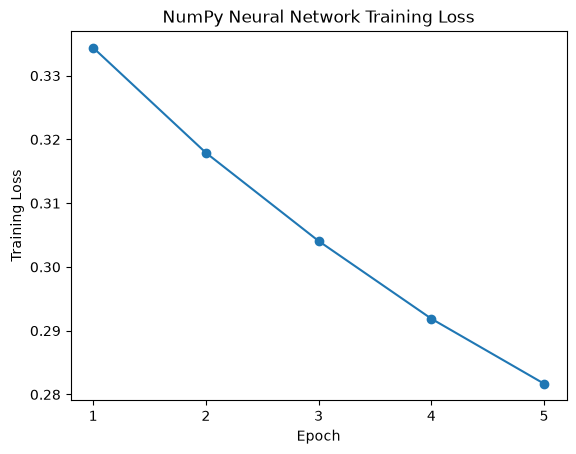

In [43]:
plt.plot(
    range(1, len(history_numpy["loss"]) + 1),
    history_numpy["loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("NumPy Neural Network Training Loss")
plt.xticks(range(1, 6))
plt.show()

In [44]:
test_accuracy = model.accuracy(X_test, y_test_labels)

print(f"NumPy Test Accuracy: {test_accuracy:.4f}")

NumPy Test Accuracy: 0.9252
